# HyDMIS — Covid-vaccine-misinfo-MIC EDA
## Health Misinformation Domain — Multilingual

**Dataset:** Covid-vaccine-misinfo-MIC — Kim et al. (2023), EMNLP  
**Records:** 5,952 annotated tweets  
**Countries:** Brazil (PT), Indonesia (ID), Nigeria (EN)  
**Labels:** Q1=1 (Misinformation), Q1=2 (Not Misinformation)  

**Critical limitation:** No tweet text — tweets deleted from Twitter. EDA covers annotation metadata only. Dataset used for cross-lingual label analysis — NOT Stage 1 LDA.

**Key findings:**
- Dis rate: 61.6% — majority misinfo dataset
- Indonesia highest dis rate (69.4%), Nigeria lowest (44.0%)
- Indonesian language (ID) dis rate 81.7% — highest by language
- Missing country (n=588) = 100% misinfo — strong metadata signal
- 82.1% annotator disagreement on misinfo records — high ambiguity

In [1]:
import sys, os, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from covid_misinfo_loader import load_covid_misinfo

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.size'] = 11
os.makedirs('../figures/eda', exist_ok=True)
COUNTRY_COLORS = {'Brazil':'#5cb85c','Indonesia':'#d9534f','Nigeria':'steelblue','Missing':'gray'}
print('Imports complete')

Imports complete


In [2]:
result = load_covid_misinfo(data_dir='../data/raw')
df = result['data']
df['is_misinfo'] = (df['Q1'] == 1).astype(int)
df['country_label'] = df['country'].fillna('Missing')
print(f'Shape: {df.shape} | Dis rate: {df["is_misinfo"].mean():.1%}')

Loading Covid-vaccine-misinfo-MIC...
  ✓ Covid-misinfo-MIC: 5,952 records | Health | EN/PT/ID
Shape: (5952, 20) | Dis rate: 61.6%


## 1. Label Distribution — Majority Misinfo

61.6% misinfo — inverted vs FakeNewsNet (24.8%). Different health domain dynamics.

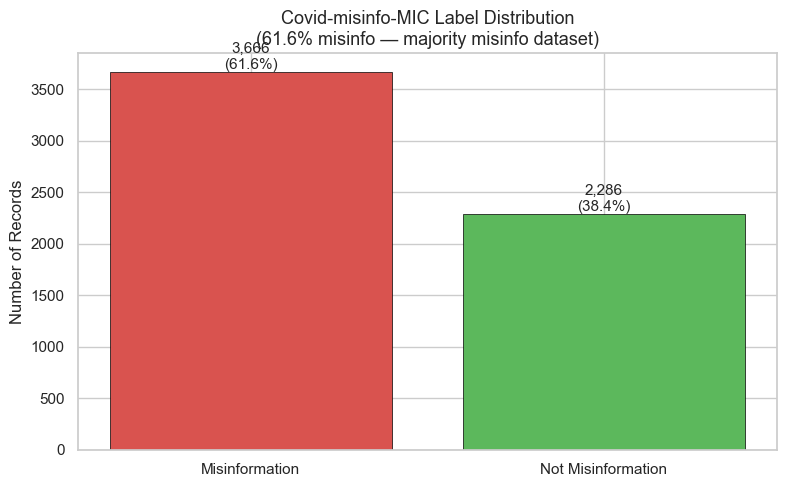

In [3]:
mis=(df['Q1']==1).sum(); cred=(df['Q1']==2).sum()
fig,ax=plt.subplots(figsize=(8,5))
bars=ax.bar(['Misinformation','Not Misinformation'],[mis,cred],color=['#d9534f','#5cb85c'],edgecolor='black',linewidth=0.5)
for bar,val in zip(bars,[mis,cred]):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+30,f'{val:,}\n({val/len(df):.1%})',ha='center',fontsize=11)
ax.set_title('Covid-misinfo-MIC Label Distribution\n(61.6% misinfo — majority misinfo dataset)',fontsize=13)
ax.set_ylabel('Number of Records')
plt.tight_layout()
plt.savefig('../figures/eda/covid_label_distribution.png',dpi=150,bbox_inches='tight')
plt.show()

## 2. Country Distribution

Indonesia (37.5%) and Nigeria (37.1%) nearly equal. Brazil smaller (15.5%). 9.9% missing country.

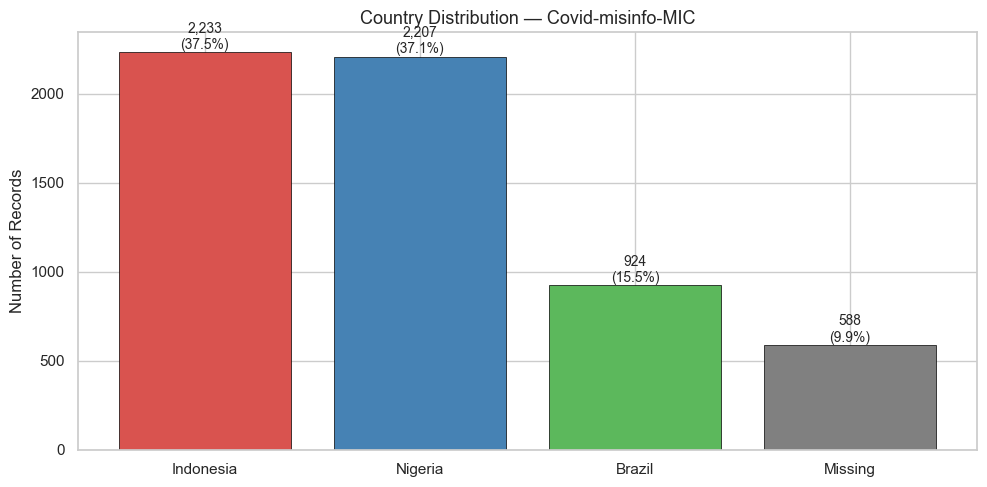

In [4]:
country_counts=df['country_label'].value_counts()
fig,ax=plt.subplots(figsize=(10,5))
colors=[COUNTRY_COLORS.get(c,'gray') for c in country_counts.index]
bars=ax.bar(country_counts.index,country_counts.values,color=colors,edgecolor='black',linewidth=0.5)
for bar,val in zip(bars,country_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+20,f'{val:,}\n({val/len(df):.1%})',ha='center',fontsize=10)
ax.set_title('Country Distribution — Covid-misinfo-MIC',fontsize=13)
ax.set_ylabel('Number of Records')
plt.tight_layout()
plt.savefig('../figures/eda/covid_country_distribution.png',dpi=150,bbox_inches='tight')
plt.show()

## 3. Disinformation Rate by Country

Indonesia 69.4% vs Nigeria 44.0% — 25.4% country gap. Missing = 100% misinfo.

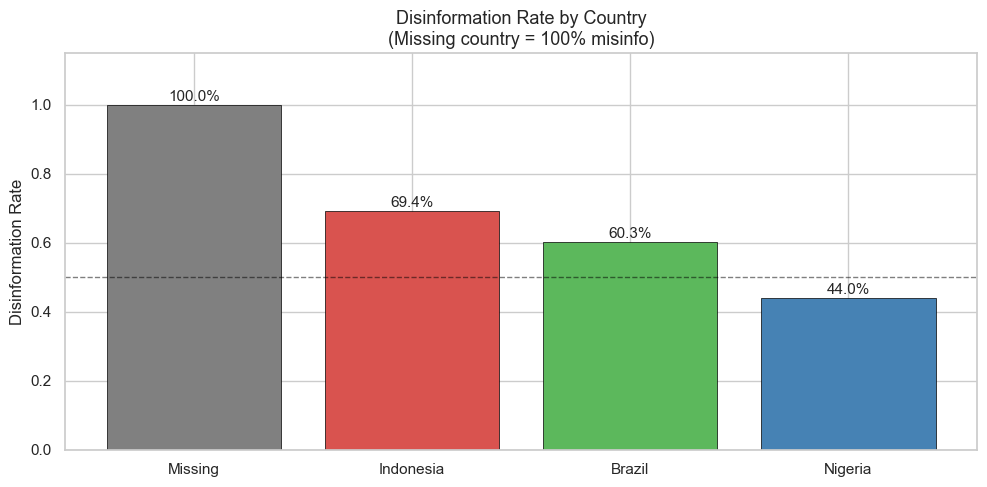

In [5]:
country_dis=df.groupby('country_label')['is_misinfo'].mean().sort_values(ascending=False)
fig,ax=plt.subplots(figsize=(10,5))
colors=[COUNTRY_COLORS.get(c,'gray') for c in country_dis.index]
bars=ax.bar(country_dis.index,country_dis.values,color=colors,edgecolor='black',linewidth=0.5)
for bar,val in zip(bars,country_dis.values):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.01,f'{val:.1%}',ha='center',fontsize=11)
ax.axhline(y=0.5,color='black',linestyle='--',linewidth=1,alpha=0.5)
ax.set_title('Disinformation Rate by Country\n(Missing country = 100% misinfo)',fontsize=13)
ax.set_ylabel('Disinformation Rate'); ax.set_ylim(0,1.15)
plt.tight_layout()
plt.savefig('../figures/eda/covid_dis_rate_by_country.png',dpi=150,bbox_inches='tight')
plt.show()

## 4. Language Distribution

EN dominates (65.9%). ID (18.6%) is primary non-English language. PT surprisingly low (2.9%).

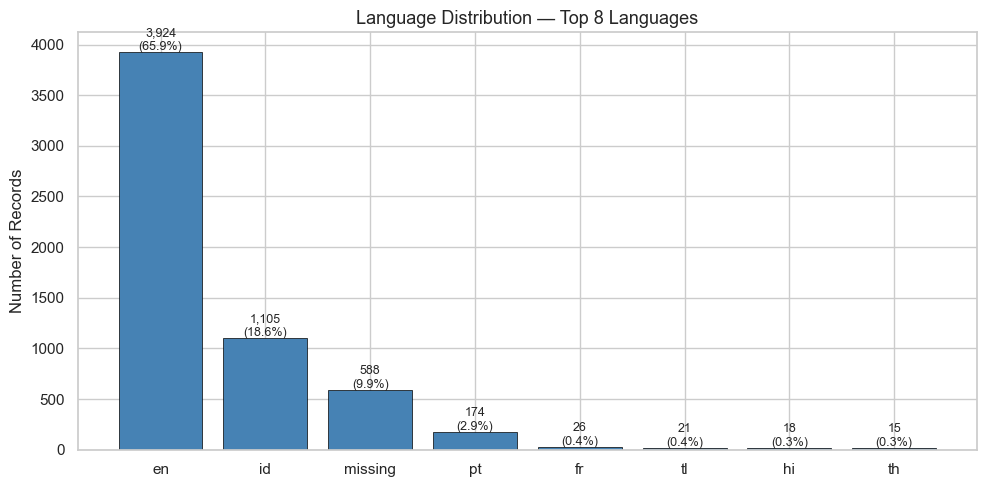

In [6]:
lang_counts=df['lang'].fillna('missing').value_counts().head(8)
fig,ax=plt.subplots(figsize=(10,5))
bars=ax.bar(lang_counts.index,lang_counts.values,color='steelblue',edgecolor='black',linewidth=0.5)
for bar,val in zip(bars,lang_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+20,f'{val:,}\n({val/len(df):.1%})',ha='center',fontsize=9)
ax.set_title('Language Distribution — Top 8 Languages',fontsize=13)
ax.set_ylabel('Number of Records')
plt.tight_layout()
plt.savefig('../figures/eda/covid_language_distribution.png',dpi=150,bbox_inches='tight')
plt.show()

## 5. Disinformation Rate by Language

ID (Indonesian) 81.7% highest. PT (Portuguese) 34.5% lowest. Wide language-based gap.

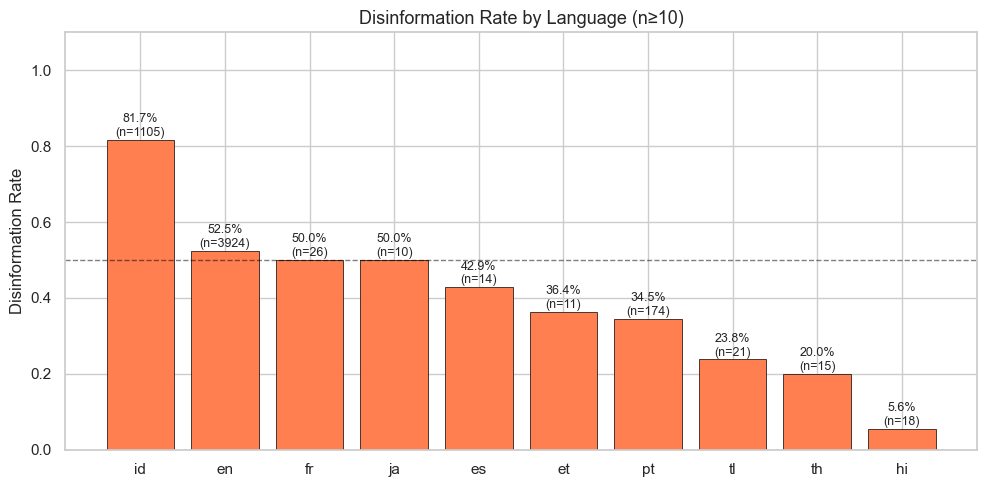

In [7]:
lang_dis=df.groupby('lang')['is_misinfo'].agg(['mean','count']).reset_index()
lang_dis=lang_dis[lang_dis['count']>=10].sort_values('mean',ascending=False)
fig,ax=plt.subplots(figsize=(10,5))
bars=ax.bar(lang_dis['lang'],lang_dis['mean'],color='coral',edgecolor='black',linewidth=0.5)
for bar,val,n in zip(bars,lang_dis['mean'],lang_dis['count']):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.01,f'{val:.1%}\n(n={n})',ha='center',fontsize=9)
ax.axhline(y=0.5,color='black',linestyle='--',linewidth=1,alpha=0.5)
ax.set_title('Disinformation Rate by Language (n≥10)',fontsize=13)
ax.set_ylabel('Disinformation Rate'); ax.set_ylim(0,1.1)
plt.tight_layout()
plt.savefig('../figures/eda/covid_dis_rate_by_language.png',dpi=150,bbox_inches='tight')
plt.show()

## 6. Country × Label Heatmap

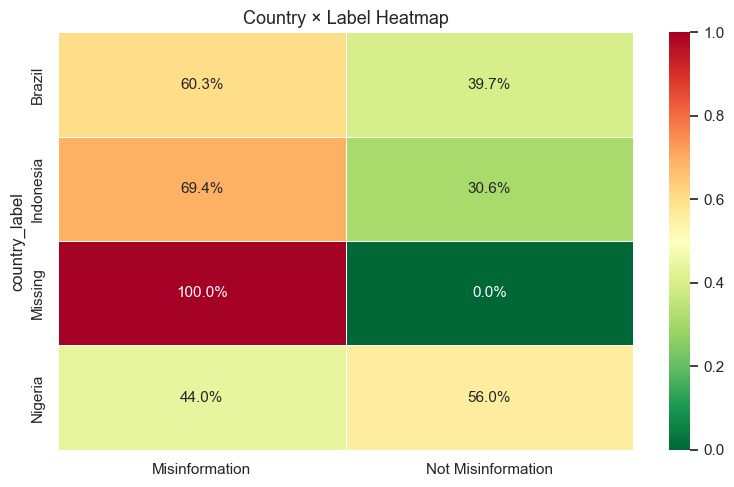

In [8]:
ct=pd.crosstab(df['country_label'],df['Q1'])
ct.columns=['Misinformation','Not Misinformation']
ct_pct=ct.div(ct.sum(axis=1),axis=0)
fig,ax=plt.subplots(figsize=(8,5))
sns.heatmap(ct_pct,annot=True,fmt='.1%',cmap='RdYlGn_r',ax=ax,linewidths=0.5)
ax.set_title('Country × Label Heatmap',fontsize=13)
plt.tight_layout()
plt.savefig('../figures/eda/covid_country_label_heatmap.png',dpi=150,bbox_inches='tight')
plt.show()

## 7. Missing Country = 100% Misinfo — Key Metadata Signal

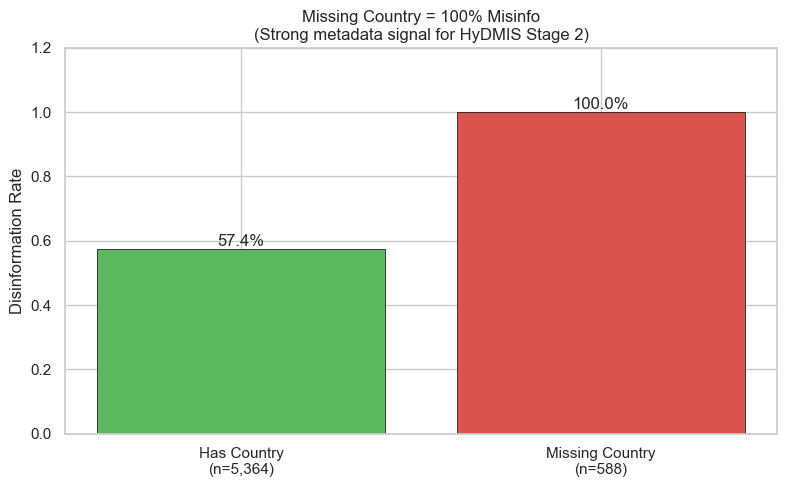

In [9]:
has_country=df['country'].notna()
groups=['Has Country\n(n={:,})'.format(has_country.sum()),'Missing Country\n(n={:,})'.format((~has_country).sum())]
rates=[df[has_country]['is_misinfo'].mean(),df[~has_country]['is_misinfo'].mean()]
fig,ax=plt.subplots(figsize=(8,5))
bars=ax.bar(groups,rates,color=['#5cb85c','#d9534f'],edgecolor='black',linewidth=0.5)
for bar,val in zip(bars,rates):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.01,f'{val:.1%}',ha='center',fontsize=12)
ax.set_title('Missing Country = 100% Misinfo\n(Strong metadata signal for HyDMIS Stage 2)',fontsize=12)
ax.set_ylabel('Disinformation Rate'); ax.set_ylim(0,1.2)
plt.tight_layout()
plt.savefig('../figures/eda/covid_missing_country_signal.png',dpi=150,bbox_inches='tight')
plt.show()

## 8. Annotation Agreement (Q2)

82.1% annotator disagreement on misinfo records — high ambiguity in health misinfo labeling.

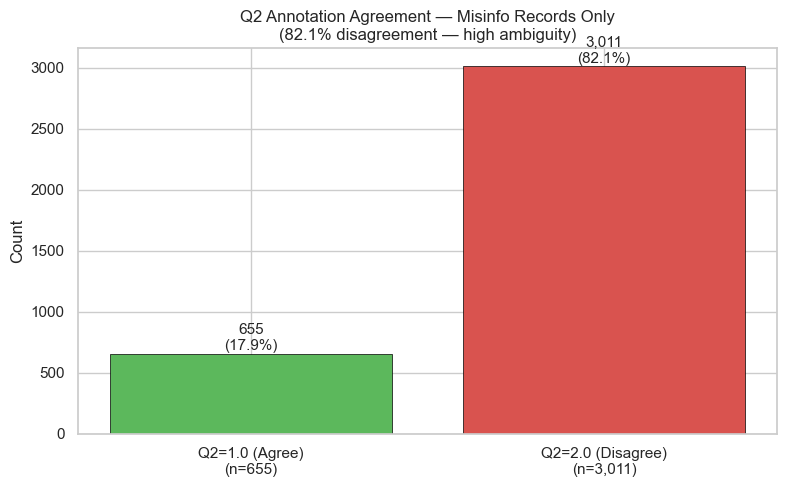

In [10]:
fig,ax=plt.subplots(figsize=(8,5))
bars=ax.bar(['Q2=1.0 (Agree)\n(n=655)','Q2=2.0 (Disagree)\n(n=3,011)'],[655,3011],
              color=['#5cb85c','#d9534f'],edgecolor='black',linewidth=0.5)
for bar,val in zip(bars,[655,3011]):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+30,
            f'{val:,}\n({val/3666:.1%})',ha='center',fontsize=11)
ax.set_title('Q2 Annotation Agreement — Misinfo Records Only\n(82.1% disagreement — high ambiguity)',fontsize=12)
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../figures/eda/covid_annotation_agreement.png',dpi=150,bbox_inches='tight')
plt.show()

## 9. Language × Country Distribution

EN dominates Nigeria, ID dominates Indonesia, PT in Brazil.

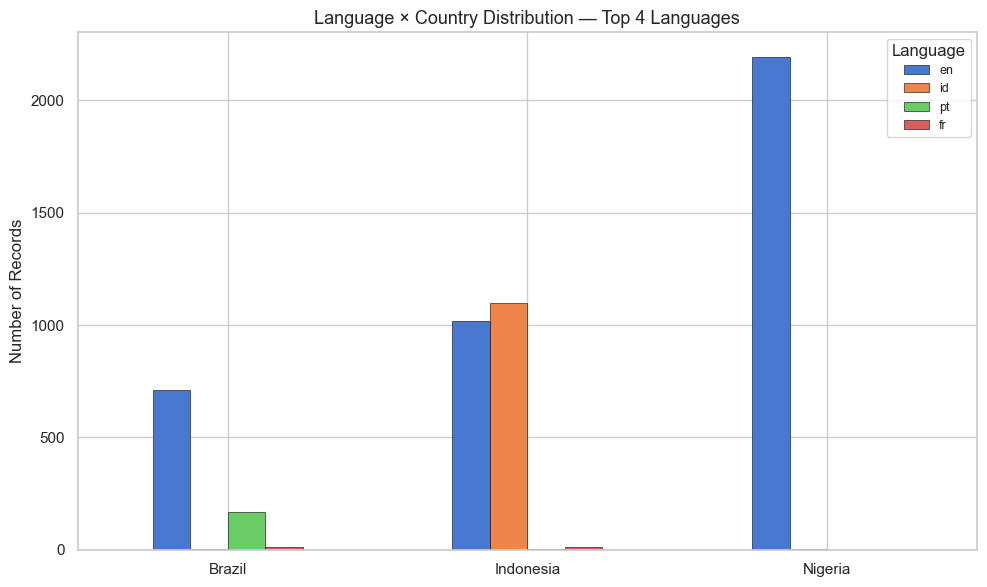

In [11]:
lang_country=df[df['country'].notna()].groupby(['country','lang']).size().unstack(fill_value=0)
top_langs=df['lang'].value_counts().head(4).index
lang_country=lang_country[[c for c in top_langs if c in lang_country.columns]]
fig,ax=plt.subplots(figsize=(10,6))
lang_country.plot(kind='bar',ax=ax,edgecolor='black',linewidth=0.4)
ax.set_title('Language × Country Distribution — Top 4 Languages',fontsize=13)
ax.set_ylabel('Number of Records'); ax.set_xlabel('')
plt.xticks(rotation=0); ax.legend(title='Language',fontsize=9)
plt.tight_layout()
plt.savefig('../figures/eda/covid_language_country.png',dpi=150,bbox_inches='tight')
plt.show()

## 10. Missing Values Overview

Q4 sub-questions 79.3% missing. Q2/Q3/Q5 38.4% missing — only available for misinfo records.

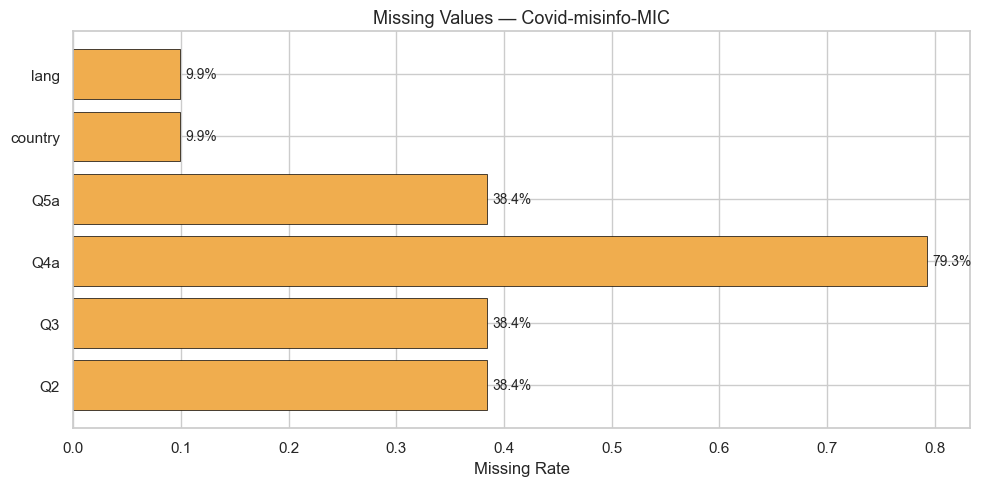

In [12]:
miss_cols=['Q2','Q3','Q4a','Q5a','country','lang']
miss_rates=[df[c].isna().mean() for c in miss_cols]
fig,ax=plt.subplots(figsize=(10,5))
bars=ax.barh(miss_cols,miss_rates,color='#f0ad4e',edgecolor='black',linewidth=0.5)
for bar,val in zip(bars,miss_rates):
    ax.text(bar.get_width()+0.005,bar.get_y()+bar.get_height()/2,f'{val:.1%}',va='center',fontsize=10)
ax.set_title('Missing Values — Covid-misinfo-MIC',fontsize=13)
ax.set_xlabel('Missing Rate')
plt.tight_layout()
plt.savefig('../figures/eda/covid_missing_values.png',dpi=150,bbox_inches='tight')
plt.show()

## 11. Key Observations

**No tweet text:** Tweets deleted from Twitter — annotation metadata only. Dataset used for cross-lingual label analysis, NOT Stage 1 LDA text modeling.

**Majority misinfo:** 61.6% dis rate — inverted vs FakeNewsNet (24.8%).

**Country gap:** Indonesia (69.4%) vs Nigeria (44.0%) — 25.4% gap.

**Missing country = 100% misinfo:** Strong metadata signal for Stage 2.

**Language signal:** ID 81.7% vs PT 34.5% — language alone predicts misinfo.

**82.1% annotator disagreement:** High ambiguity in health misinfo labeling — validates need for Stage 2 LLM semantic verification.